# 🌾 Crop Recommendation System

**Goal:** Given soil nutrients (N, P, K, pH) and climate data (temperature, humidity, rainfall), predict the best crop to plant.

**Dataset:** [Kaggle — Crop Recommendation](https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset)  
**Model:** Random Forest Classifier  

---

### Steps
1. Load & Explore Data
2. Visualize (EDA)
3. Prepare features
4. Train & compare models
5. Evaluate best model
6. Make predictions
7. Save model

##  Step 0 — Install Libraries

In [1]:
# Run this once
!pip install pandas numpy matplotlib seaborn scikit-learn streamlit

##  Step 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


##  Step 2 — Load the Dataset

In [3]:
# Make sure Crop_recommendation.csv is in the same folder
df = pd.read_csv('Crop_recommendation.csv')

print(f'Shape       : {df.shape}')              # (2200, 8)
print(f'Columns     : {list(df.columns)}')
print(f'Crop classes: {df["label"].nunique()}  →  {list(df["label"].unique())}')
print(f'Missing vals: {df.isnull().sum().sum()}')

df.head(10)

Shape       : (2200, 8)
Columns     : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
Crop classes: 22  →  ['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas', 'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate', 'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple', 'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee']
Missing vals: 0


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [4]:
# Statistical summary
df.describe().round(2)

,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


In [5]:
# Samples per crop (should be 100 each)
df['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

##  Step 3 — Exploratory Data Analysis (EDA)

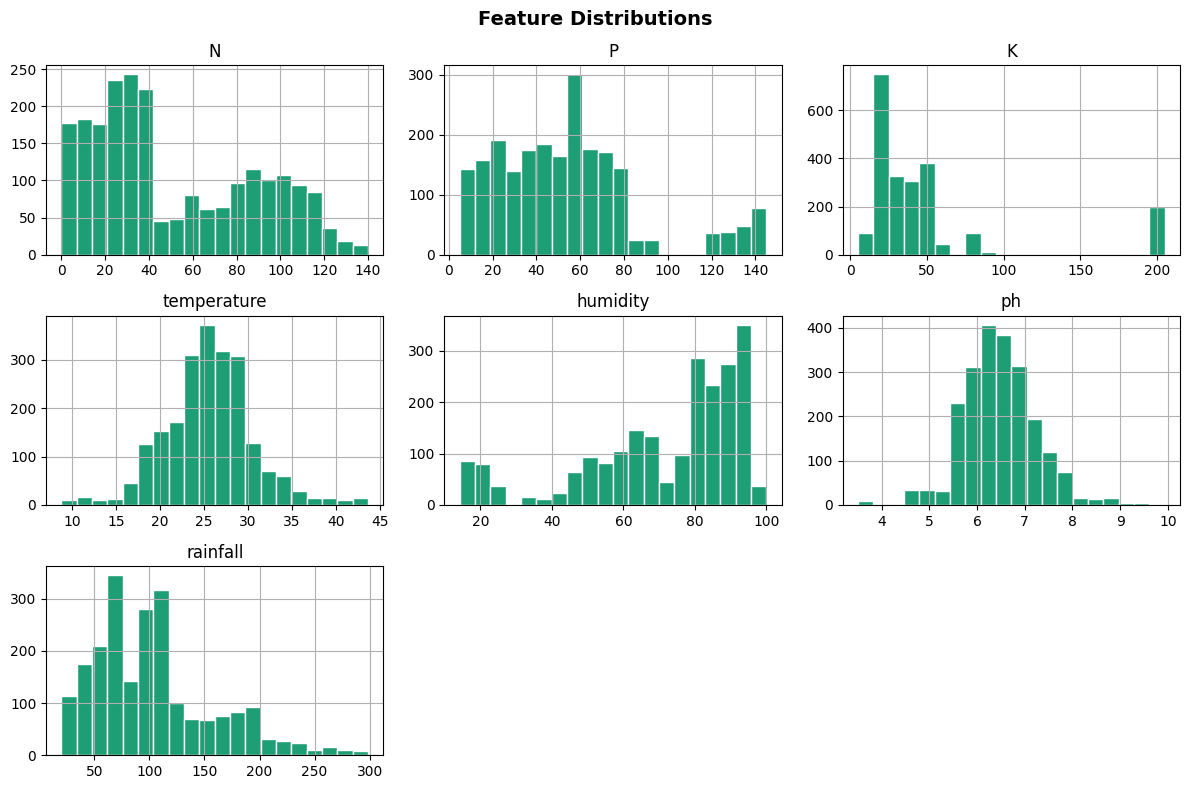

In [6]:
# 3a. Feature distributions
df.drop('label', axis=1).hist(figsize=(12, 8), bins=20, color='#1D9E75', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

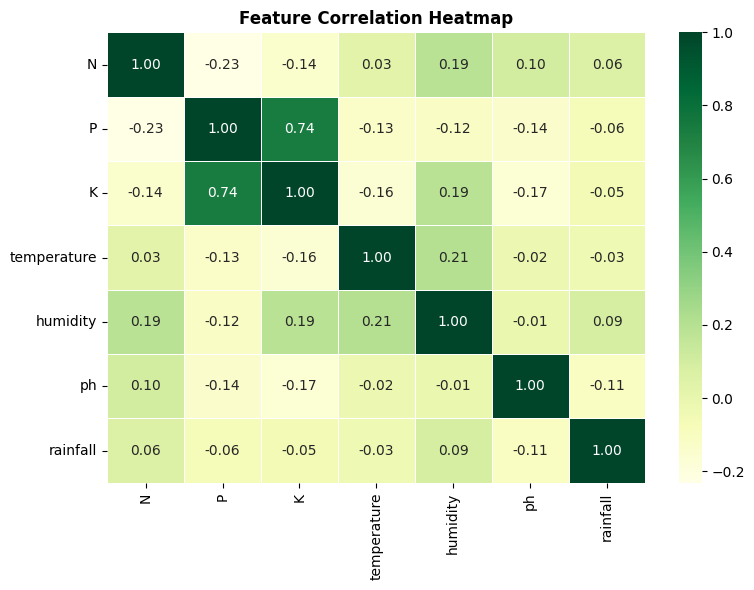

In [7]:
# 3b. Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

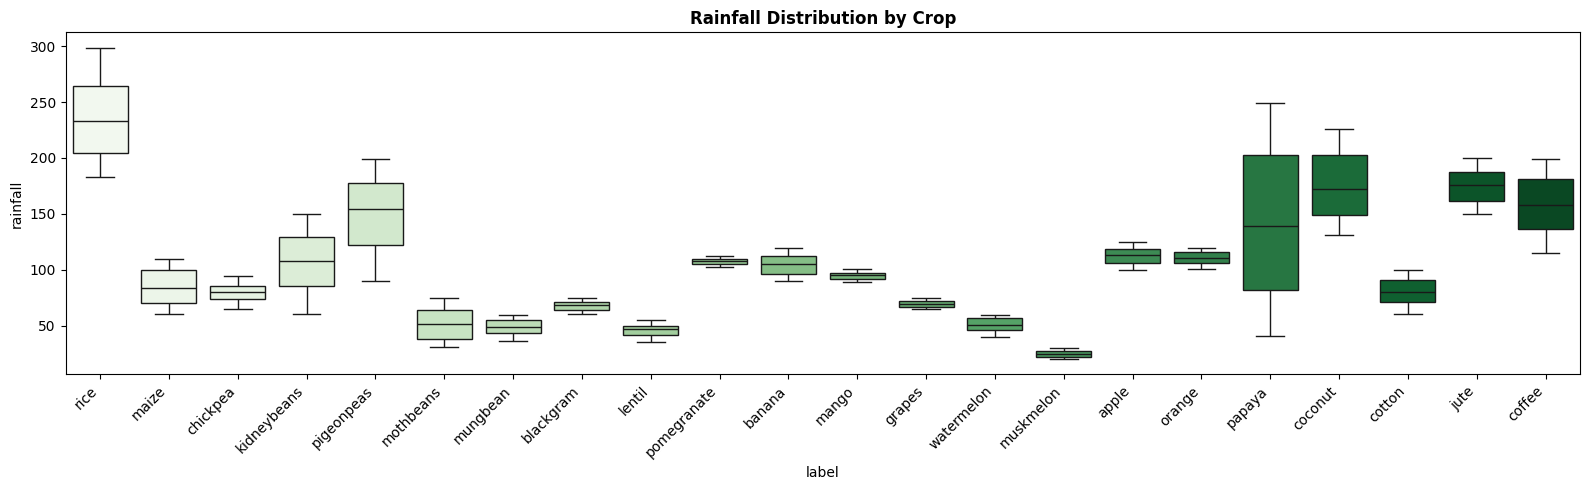

In [8]:
# 3c. Rainfall by crop
plt.figure(figsize=(16, 5))
sns.boxplot(x='label', y='rainfall', data=df, palette='Greens')
plt.title('Rainfall Distribution by Crop', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

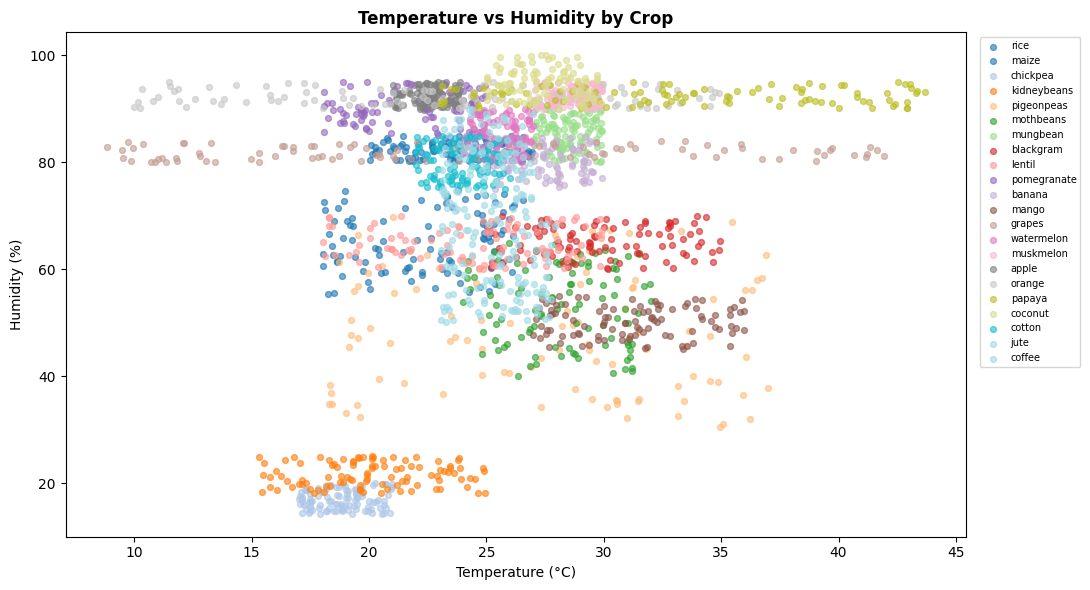

In [9]:
# 3d. Temperature vs Humidity coloured by crop
plt.figure(figsize=(11, 6))
crops  = df['label'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(crops)))
for crop, color in zip(crops, colors):
    sub = df[df['label'] == crop]
    plt.scatter(sub['temperature'], sub['humidity'], label=crop, color=color, alpha=0.6, s=18)
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.title('Temperature vs Humidity by Crop', fontweight='bold')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

##  Step 4 — Prepare Data for Training

In [10]:
X = df.drop('label', axis=1)   # Features (inputs)
y = df['label']                 # Target  (output)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')
print(f'Features         : {list(X.columns)}')

Training samples : 1760
Testing  samples : 440
Features         : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


##  Step 5 — Train & Compare Models

Random Forest         Accuracy: 0.9932  (99.32%)
Decision Tree         Accuracy: 0.9864  (98.64%)
KNN (k=5)             Accuracy: 0.9705  (97.05%)
Naive Bayes           Accuracy: 0.9955  (99.55%)


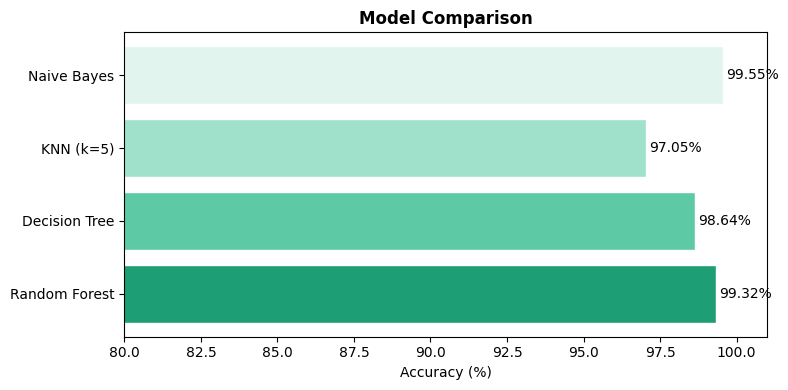

In [11]:
models = {
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree' : DecisionTreeClassifier(random_state=42),
    'KNN (k=5)'     : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'   : GaussianNB(),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds       = model.predict(X_test)
    acc         = accuracy_score(y_test, preds)
    results[name] = acc
    print(f'{name:<20}  Accuracy: {acc:.4f}  ({acc*100:.2f}%)')

# Plot comparison
plt.figure(figsize=(8, 4))
plt.barh(list(results.keys()), [v*100 for v in results.values()],
         color=['#1D9E75','#5DCAA5','#9FE1CB','#E1F5EE'], edgecolor='white')
plt.xlabel('Accuracy (%)')
plt.title('Model Comparison', fontweight='bold')
plt.xlim(80, 101)
for i, (k, v) in enumerate(results.items()):
    plt.text(v*100+0.1, i, f'{v*100:.2f}%', va='center')
plt.tight_layout()
plt.show()

##  Step 6 — Evaluate Best Model (Random Forest)

In [12]:
rf     = models['Random Forest']
y_pred = rf.predict(X_test)

print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
    

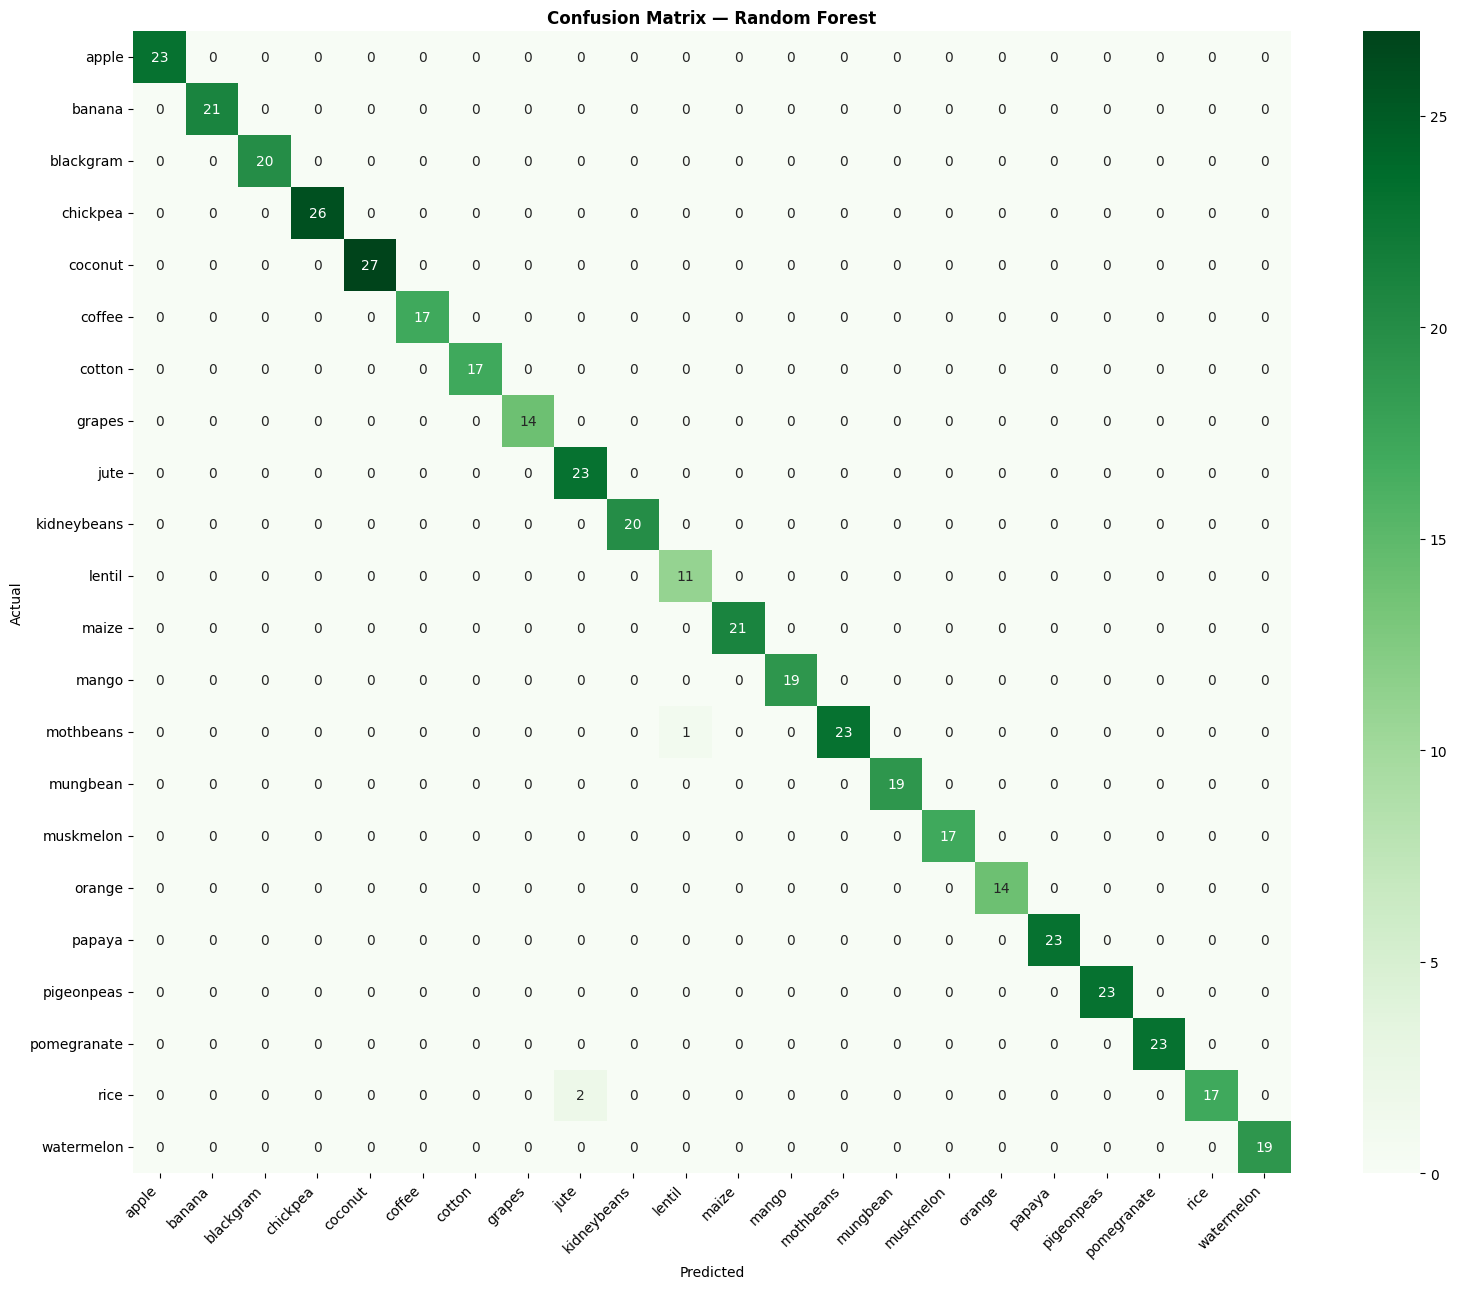

In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.title('Confusion Matrix — Random Forest', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

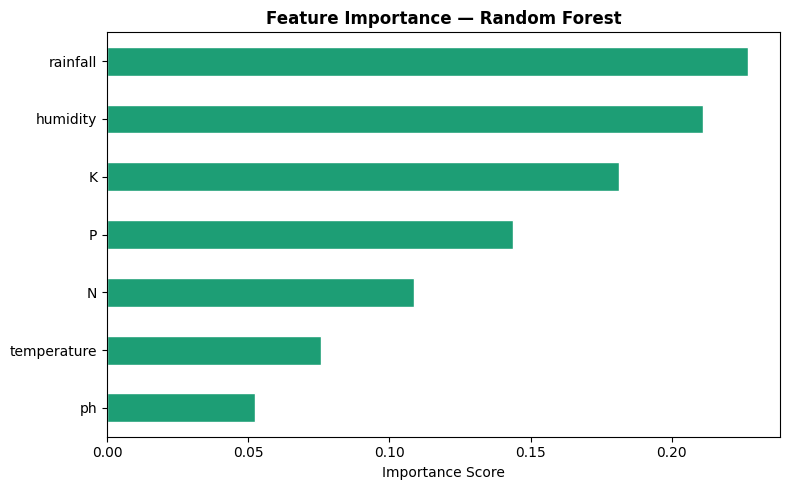


Importance values:
rainfall       0.227036
humidity       0.211279
K              0.181222
P              0.143622
N              0.108859
temperature    0.075682
ph             0.052301


In [14]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#1D9E75', edgecolor='white')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nImportance values:')
print(importances.sort_values(ascending=False).to_string())

##  Step 7 — Save the Model

In [15]:
with open('crop_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

print('✅ Model saved as crop_model.pkl')

✅ Model saved as crop_model.pkl


##  Step 8 — Make Predictions

In [16]:
# Load saved model (as you would in production)
with open('crop_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# ─── Try your own values here! ───────────────────────
N         = 90    # Nitrogen   (0–140)
P         = 42    # Phosphorus (5–145)
K         = 43    # Potassium  (5–205)
temp      = 21    # Temperature°C (8–44)
humidity  = 82    # Humidity % (14–100)
ph        = 6.5   # Soil pH   (3.5–10)
rainfall  = 202   # Rainfall mm (20–300)
# ─────────────────────────────────────────────────────

input_arr  = np.array([[N, P, K, temp, humidity, ph, rainfall]])
prediction = loaded_model.predict(input_arr)[0]
confidence = loaded_model.predict_proba(input_arr).max()

print(f'Input    : N={N}, P={P}, K={K}, Temp={temp}°C, Humidity={humidity}%, pH={ph}, Rainfall={rainfall}mm')
print(f'Crop     : {prediction.upper()}')
print(f'Confidence: {confidence:.1%}')

Input    : N=90, P=42, K=43, Temp=21°C, Humidity=82%, pH=6.5, Rainfall=202mm
Crop     : RICE
Confidence: 98.0%


In [55]:
# Top 5 crop probabilities for your input
proba     = loaded_model.predict_proba(input_arr)[0]
top5_idx  = proba.argsort()[::-1][:5]
top5      = pd.DataFrame({
    'Crop'      : loaded_model.classes_[top5_idx],
    'Confidence': [f'{proba[i]:.1%}' for i in top5_idx]
})
print('Top 5 Recommendations:')
top5

Top 5 Recommendations:


,Crop,Confidence
0,rice,98.0%
1,jute,2.0%
2,watermelon,0.0%
3,banana,0.0%
4,blackgram,0.0%


##  Step 9 — Launch the Web page